# Data loading 

In [19]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             average_precision_score)



# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [20]:
countries = pd.read_csv("datasets/countries.csv")
currency = pd.read_csv("datasets/currency_details.csv")
transactions = pd.read_csv("datasets/transactions.csv")
users = pd.read_csv("datasets/users.csv")

# Data Exploration 

### initial inspection of countries dataset

In [21]:
countries.head(10)

,CODE,NAME,CODE3,NUMCODE,PHONECODE
0,AF,Afghanistan,AFG,4,93
1,AL,Albania,ALB,8,355
2,DZ,Algeria,DZA,12,213
3,AS,American Samoa,ASM,16,1684
4,AO,Angola,AGO,24,244
5,AI,Anguilla,AIA,660,1264
6,AG,Antigua and Barbuda,ATG,28,1268
7,AR,Argentina,ARG,32,54
8,AM,Armenia,ARM,51,374
9,AW,Aruba,ABW,533,297


In [22]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CODE       225 non-null    object
 1   NAME       226 non-null    object
 2   CODE3      226 non-null    object
 3   NUMCODE    226 non-null    int64 
 4   PHONECODE  226 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 9.0+ KB


the basic structure of countries dataset is clear , we now know all the number of records, column, data types, and where empty values exist 


### initial inspection of currency dataset

In [23]:
currency.head(10)

,CCY,EXPONENT,IS_CRYPTO
0,AED,2,False
1,AFN,2,False
2,ALL,2,False
3,AMD,2,False
4,ANG,2,False
5,AOA,2,False
6,ARS,2,False
7,AUD,2,False
8,AWG,2,False
9,AZN,2,False


In [24]:
currency.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CCY        184 non-null    object
 1   EXPONENT   184 non-null    int64 
 2   IS_CRYPTO  184 non-null    bool  
dtypes: bool(1), int64(1), object(1)
memory usage: 3.2+ KB


In [25]:
currency.tail()

,CCY,EXPONENT,IS_CRYPTO
179,ZMW,2,False
180,ZWD,2,False
181,ZWL,2,False
182,XRP,6,True
183,BCH,8,True


After reviewing this output, the structure of the currency table is fully understood. We can confirm that all fields are complete, distinguish categorical, numeric, and boolean columns, and confidently integrate this dataset into transaction-level processing and feature engineering.

### initial inspection of transactions dataset

In [26]:
transactions.head(10)

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN
2,GBP,191,COMPLETED,2017-12-10 16:37:16.234,airport,PRT,chip,7bcaa34e-b889-4582-9c29-0b3bab34fb8c,CARD_PAYMENT,GAIA,ddb4a930-7d8a-4f38-9079-ddc4b0db980e,141.0
3,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,NaN,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0
4,EUR,1159,COMPLETED,2017-12-10 16:34:17.88,NaN,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,bd13abac-4004-4c67-9bb7-90a42b027e82,977.0
5,EUR,680,COMPLETED,2017-12-10 16:51:10.791,restaurant,DEU,chip,3c1aa14d-818a-474f-847f-3d24907dd1c7,CARD_PAYMENT,GAIA,99be2b3c-84d7-4522-96b3-8d834e67132f,573.0
6,USD,357,COMPLETED,2017-12-10 16:50:34.338,NaN,USA,manu,2a6f8724-87e0-481a-8081-a3aed97f48f0,CARD_PAYMENT,GAIA,23144387-74ab-4161-a131-e4b1e7bc86d6,357.0
7,GBP,6447,COMPLETED,2017-12-10 16:49:30.912,restaurant,GBR,chip,6d8e8a8a-86d3-4291-b2d9-3c6d1a857f5e,CARD_PAYMENT,GAIA,aa1e3dd7-89dd-41a7-bac2-5cd2caae74c3,4767.0
8,GBP,3335,COMPLETED,2017-12-10 16:48:38.372,NaN,GBR,chip,cbcf5219-8623-4a49-a095-f2797c843b39,CARD_PAYMENT,GAIA,a8679f08-a309-45f3-86c1-2cbc8a9de378,2466.0
9,EUR,1430,COMPLETED,2017-12-10 16:47:51.308,transit_station,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,f20f926f-8f12-415d-95bb-88cc24f578f7,1206.0


In [27]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CURRENCY           688651 non-null  object 
 1   AMOUNT             688651 non-null  int64  
 2   STATE              688651 non-null  object 
 3   CREATED_DATE       688651 non-null  object 
 4   MERCHANT_CATEGORY  223065 non-null  object 
 5   MERCHANT_COUNTRY   483055 non-null  object 
 6   ENTRY_METHOD       688651 non-null  object 
 7   USER_ID            688651 non-null  object 
 8   TYPE               688651 non-null  object 
 9   SOURCE             688651 non-null  object 
 10  ID                 688651 non-null  object 
 11  AMOUNT_USD         635328 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 63.0+ MB


In [28]:
transactions.isnull().sum()

CURRENCY                  0
AMOUNT                    0
STATE                     0
CREATED_DATE              0
MERCHANT_CATEGORY    465586
MERCHANT_COUNTRY     205596
ENTRY_METHOD              0
USER_ID                   0
TYPE                      0
SOURCE                    0
ID                        0
AMOUNT_USD            53323
dtype: int64

the transaction dataset is clear and understood , all fields are clear , but there is some missing values to handle in the preprocessing step, before any transformations or join are applied 


In [29]:
users.head(10)

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,False,2018-05-25,2017-08-06 07:33:33.341000,ACTIVE,GB,1971,PASSED,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,False,2018-01-01,2017-03-07 10:18:59.427000,ACTIVE,GB,1982,PASSED,0
2,10376f1a-a28a-4885-8daa-c8ca496026bb,1,ES,False,2018-09-20,2018-05-31 04:41:24.672000,ACTIVE,ES,1973,PASSED,0
3,fd308db7-0753-4377-879f-6ecf2af14e4f,1,FR,False,2018-05-25,2018-06-01 17:24:23.852000,ACTIVE,FR,1986,PASSED,0
4,755fe256-a34d-4853-b7ca-d9bb991a86d3,1,GB||JE||IM||GG,False,2018-09-20,2017-08-09 15:03:33.945000,ACTIVE,GB,1989,PASSED,0
5,1cc43441-bb77-47ef-98e5-4af09ccf3c83,1,GB||JE||IM||GG,False,2018-03-20,2017-12-30 16:44:36.223000,ACTIVE,GB,1979,PASSED,0
6,5a9bae2c-db88-4744-b710-644fa625c7bb,1,FR,False,2018-03-20,2016-02-17 18:16:20.933000,ACTIVE,FR,1992,PASSED,0
7,60b99cff-7bf8-44e8-9ebf-9fd59d9cbca2,1,SI,False,2018-05-25,2017-01-07 11:02:29.410000,ACTIVE,SI,1992,PASSED,0
8,25356d21-d942-47d5-b3a9-d521c79a2ae6,1,PL,False,2018-01-13,2017-12-15 17:22:24.663000,ACTIVE,PL,1983,NONE,0
9,fb125ed6-c85c-47b3-bb96-3493683659b8,1,GB||JE||IM||GG,False,2018-05-25,2017-08-17 15:59:21.351000,ACTIVE,GB,1980,PASSED,0


In [30]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       9944 non-null   object
 1   HAS_EMAIL                9944 non-null   int64 
 2   PHONE_COUNTRY            9944 non-null   object
 3   IS_FRAUDSTER             9944 non-null   bool  
 4   TERMS_VERSION            8417 non-null   object
 5   CREATED_DATE             9944 non-null   object
 6   STATE                    9944 non-null   object
 7   COUNTRY                  9944 non-null   object
 8   BIRTH_YEAR               9944 non-null   int64 
 9   KYC                      9944 non-null   object
 10  FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64 
dtypes: bool(1), int64(3), object(7)
memory usage: 786.7+ KB


In [31]:
users.isna().sum()

ID                            0
HAS_EMAIL                     0
PHONE_COUNTRY                 0
IS_FRAUDSTER                  0
TERMS_VERSION              1527
CREATED_DATE                  0
STATE                         0
COUNTRY                       0
BIRTH_YEAR                    0
KYC                           0
FAILED_SIGN_IN_ATTEMPTS       0
dtype: int64

In [32]:
users.tail(10)

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
9934,e53276ac-25af-4000-bede-80ceaeb096cd,0,GB||JE||IM||GG,False,NaN,2017-01-17 17:23:22.178000,ACTIVE,GB,1972,NONE,0
9935,06453995-2ee9-4627-8ee6-33ac086497c2,1,ES,False,2018-05-25,2018-06-08 13:34:36.553000,ACTIVE,ES,1967,NONE,0
9936,01ab82ab-ea7a-470a-94ba-4fc2b819eca9,1,PL,False,NaN,2016-10-18 11:12:52.340000,ACTIVE,PL,1992,NONE,0
9937,0e92dd75-e851-47fa-a78c-02e2dafd4a3b,1,FR,False,2018-05-25,2017-09-27 08:46:04.094000,ACTIVE,FR,1996,PASSED,0
9938,06b58502-a8fc-4fb6-a446-390ee81a141c,1,IE,False,2018-05-25,2018-07-14 07:41:37.833000,ACTIVE,IE,1990,PASSED,0
9939,544777fa-b18b-4b9e-bcdc-7e10f4e0712c,1,GB||JE||IM||GG,False,NaN,2017-01-27 18:23:38.486000,ACTIVE,GB,1998,PASSED,0
9940,438f235a-3f6e-4663-ba95-fa107b11bfc5,1,LT,False,2018-01-13,2017-12-20 11:00:03.873000,ACTIVE,LT,1994,NONE,0
9941,268d4b0a-dd32-4ca3-ba6f-d571a1fd9428,1,PT,False,2018-05-25,2018-07-11 10:12:00.098000,ACTIVE,PT,1958,PASSED,0
9942,55995ada-5797-4f7e-82da-62a3d4051e8b,1,GB||JE||IM||GG,False,2018-03-20,2018-02-23 16:24:40.716000,ACTIVE,GB,1961,NONE,0
9943,66c936f2-f22c-4f68-9dbe-567c0ca653fa,1,PT,False,2018-01-01,2017-12-10 15:40:42.304000,ACTIVE,PT,1995,NONE,0


the users dataset is structered, it appears complete for the stard to the end with some missing values in the TERMS_VERSION Feature that we need to handle after before implementing the classification models, so dataset seems ready to be safely joined with the transactions for modeling and analysis 

# Initial Data Analysis

before building any model , lets analyse the diribution of our target feature (Is_Fraudster) and it_s relationship with the other features especillay (KYC)

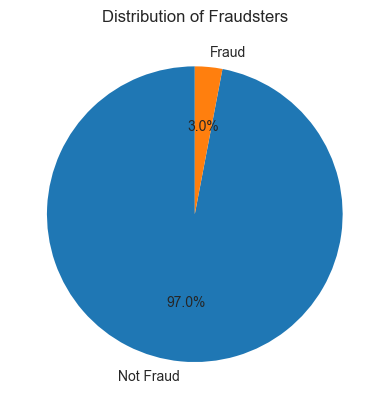

In [33]:
fraud_counts = users["IS_FRAUDSTER"].value_counts()


plt.pie(
    fraud_counts,
    labels=["Not Fraud", "Fraud"],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Distribution of Fraudsters")
plt.show()


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

kyc_percent = pd.crosstab(
    users["KYC"],
    users["IS_FRAUDSTER"],
    normalize="index"
)*100


print(kyc_percent)



IS_FRAUDSTER      False      True 
KYC                               
FAILED        91.851852   8.148148
NONE          99.961992   0.038008
PASSED        96.283541   3.716459
PENDING       78.378378  21.621622


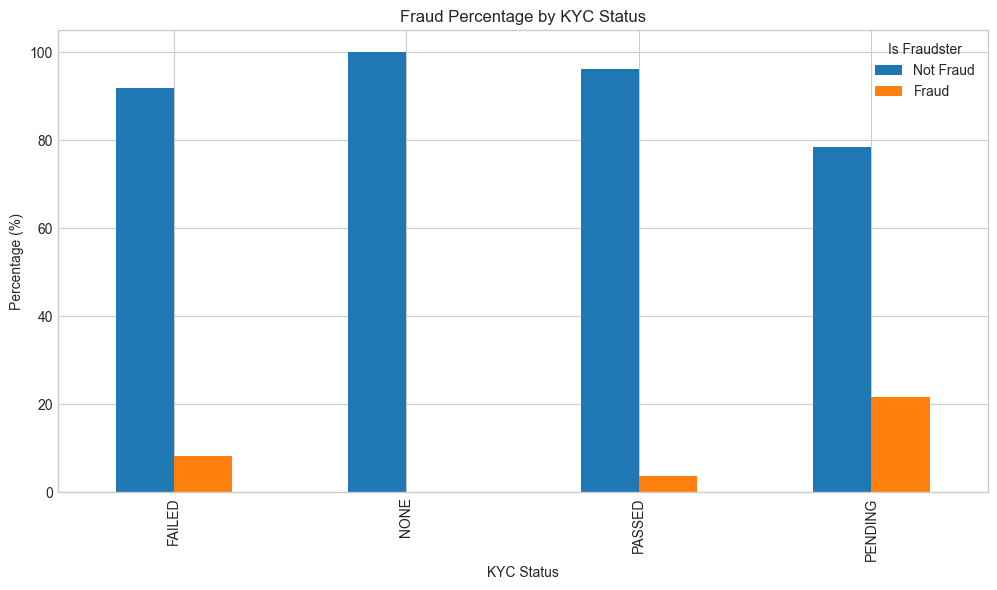

In [35]:
kyc_percent.plot(
    kind="bar",
    figsize=(12,6),
)

plt.title("Fraud Percentage by KYC Status")
plt.ylabel("Percentage (%)")
plt.xlabel("KYC Status")
plt.legend(title="Is Fraudster", labels=["Not Fraud", "Fraud"])
plt.show()


Key Observations :  

 - We notice that only 3% of the data are Fraudsters , 
 - the severe class implance will be important to adress during modelling
 - PENDING KYC has the highest fraud rate (~22%) - fraudsters may rush transactions before verification completes 
 - NONE KYC shows almost 0% fraud - likely because these accounts have restricted functionality 
 - PASSED and FAILED KYC have moderate fraud rates


## Transactions behaviour analysis 

Let's examine how transaction patterns differ between fraudsters and non-fraudsters. We'll analyze transaction amounts (using log scale for better visualization) and transaction types.

.loc est l’indexeur basé sur les labels dans pandas.
Il sert à sélectionner des lignes et/ou colonnes en utilisant les noms (labels), pas les positions numériques.
.loc[ lignes , colonnes ]    

Text(0.5, 1.0, 'transaction type distibution')

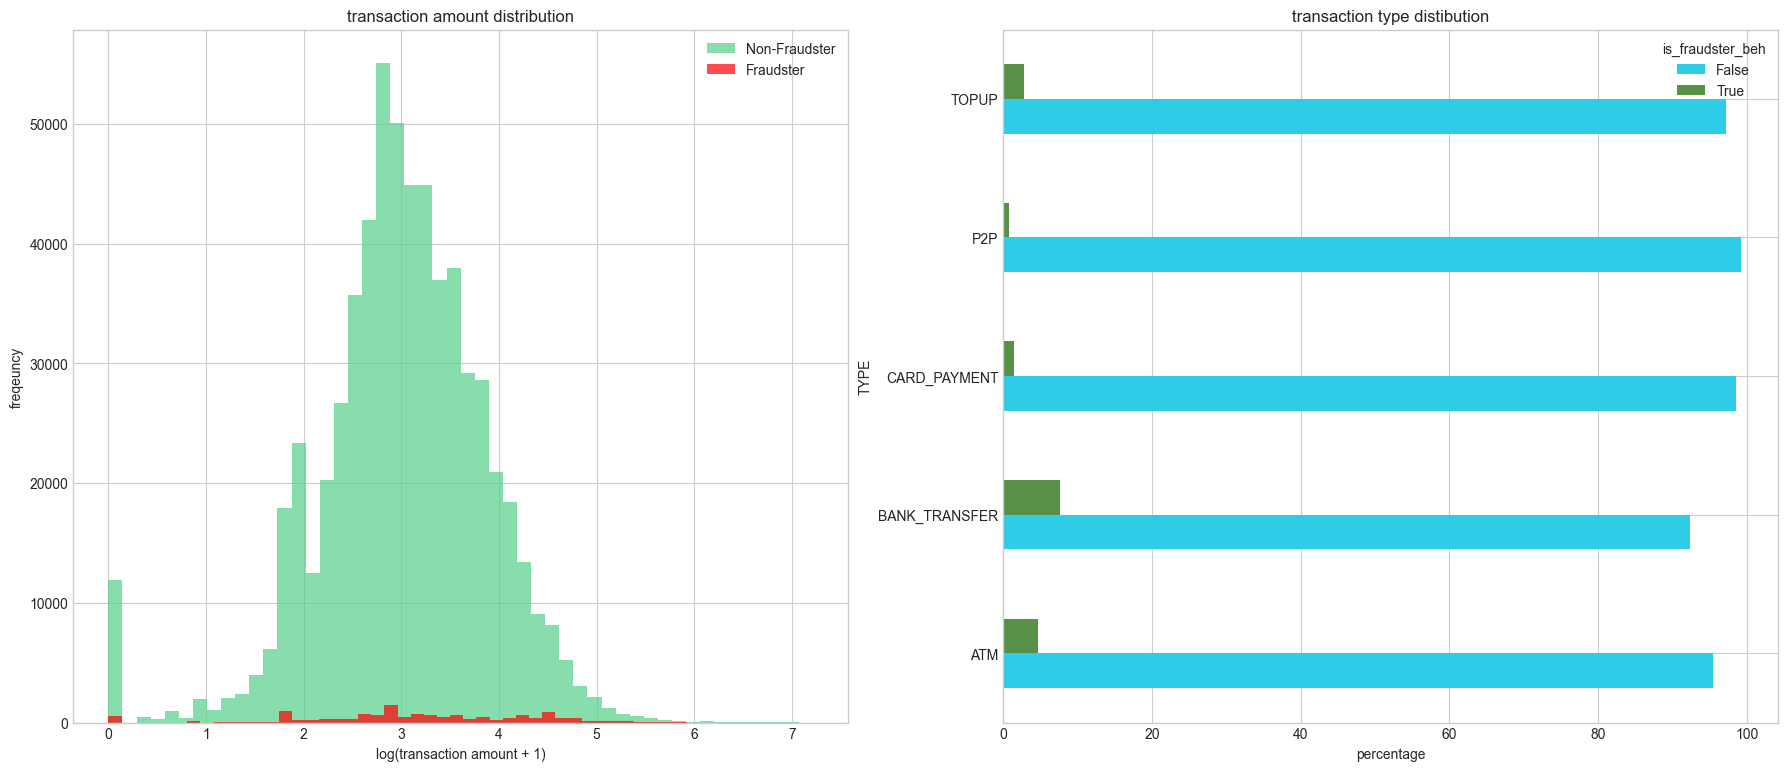

In [36]:

fraudsters_ids_beh = set(users.loc[users["IS_FRAUDSTER"] == True , "ID"])
transactions["is_fraudster_beh"] = transactions["USER_ID"].isin(fraudsters_ids_beh) 

fig_beh, axes_beh = plt.subplots(1, 2, figsize=(22, 9)) 

fraud_amount_beh = transactions.loc[transactions["is_fraudster_beh"] == True , "AMOUNT_USD"].dropna()
normal_amount_beh = transactions.loc[transactions["is_fraudster_beh"] == False , "AMOUNT_USD"].dropna()

axes_beh[0].hist(np.log10(normal_amount_beh + 1), bins=50, alpha=0.7,
                label="Non-Fraudster", color="#55d189")

axes_beh[0].hist(np.log10(fraud_amount_beh + 1), bins=50, alpha=0.7,
                label="Fraudster", color="red") 

axes_beh[0].set_title("transaction amount distribution")
axes_beh[0].set_xlabel("log(transaction amount + 1)")
axes_beh[0].set_ylabel("freqeuncy")
axes_beh[0].legend()
#--------------------------- 2nd figure -----------------------------# 

tx_type_fraud_beh = transactions.groupby(["TYPE","is_fraudster_beh"]).size().unstack()
tx_type_perc  = tx_type_fraud_beh.div(tx_type_fraud_beh.sum(axis = 1) , axis=0)*100 
tx_type_perc.plot(kind="barh", ax=axes_beh[1], color=["#2ecce7","#579047"]) 
axes_beh[1].set_xlabel("percentage")
axes_beh[1].set_title("transaction type distibution")


Key Findings
Transaction Amounts (Left Plot):

 - Fraudsters (red) show a right-skewed distribution toward higher amounts (log10 values 4-6)
Non-fraudsters (green) concentrate around lower amounts (log10 values 2-3)
This translates to fraudsters averaging 30,000 compared to 500 for non-fraudsters

Transaction Types (Right Plot):

 - BANK_TRANSFER: Dominated by fraudsters (~40%) - enables quick cash-out
 - ATM: Higher fraud proportion (~25%) - immediate cash withdrawal
 - P2P & CARD_PAYMENT: Dominated by non-fraudsters - normal everyday usage
 - TOPUP: Mixed usage, slightly higher fraud proportion
 - These behavioral differences will be valuable features for our fraud detection model. 

In [37]:
transactions

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD,is_fraudster_beh
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0,False
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN,False
2,GBP,191,COMPLETED,2017-12-10 16:37:16.234,airport,PRT,chip,7bcaa34e-b889-4582-9c29-0b3bab34fb8c,CARD_PAYMENT,GAIA,ddb4a930-7d8a-4f38-9079-ddc4b0db980e,141.0,False
3,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,NaN,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0,False
4,EUR,1159,COMPLETED,2017-12-10 16:34:17.88,NaN,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,bd13abac-4004-4c67-9bb7-90a42b027e82,977.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
688646,GBP,1727,COMPLETED,2017-12-10 16:31:45.239,point_of_interest,USA,mags,80431c45-ffdb-4399-959b-7bc400d7ea54,CARD_PAYMENT,GAIA,021ebd5d-3b1f-4133-a94a-b3b7b07500c8,1277.0,False
688647,GBP,1807,COMPLETED,2017-12-10 16:30:42.774,NaN,LUX,manu,c2b50874-5091-44be-969c-6e3b4578f668,CARD_PAYMENT,GAIA,2fb06b3e-8778-4681-a039-fd852eb67352,1332.0,False
688648,EUR,3465,COMPLETED,2017-12-10 16:30:34.972,supermarket,LTU,chip,3f8c39e2-8970-4d25-bd3f-733bb5b4c3cd,CARD_PAYMENT,GAIA,053ff016-4628-4507-b65b-b1514a74836d,2915.0,False
688649,EUR,5000,COMPLETED,2017-12-10 16:30:23.285,NaN,NaN,misc,a2e41203-a8f5-4744-97ca-dfb04479cde9,TOPUP,HERA,c3c9caec-bb96-4b6c-8af0-f4353086baf3,4207.0,False


<Axes: title={'center': 'state of transactions distribution'}, xlabel='STATE'>

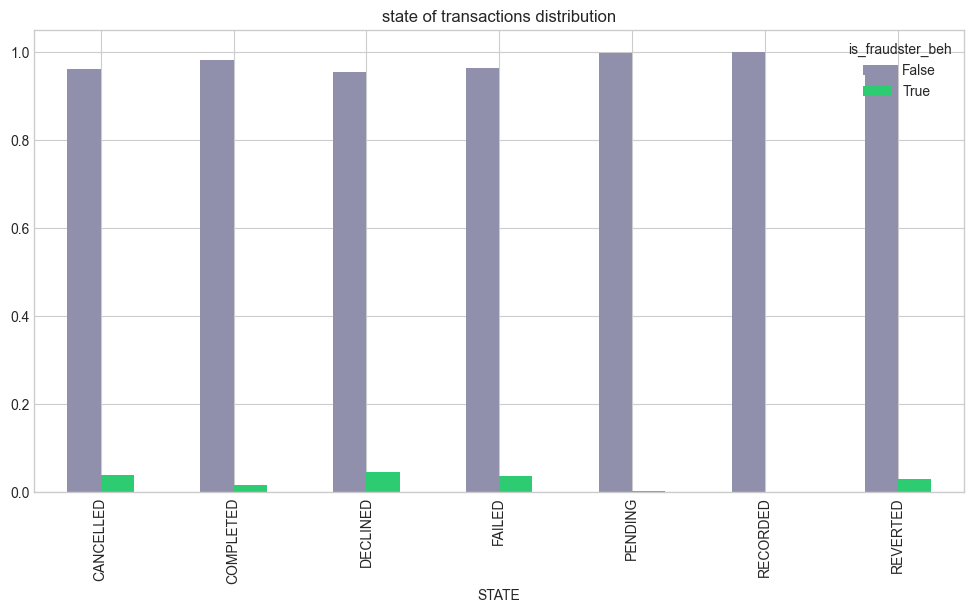

In [46]:
state_fraud = transactions.groupby(["STATE","is_fraudster_beh"]).size().unstack()
state_fraud_perc = state_fraud.div(state_fraud.sum(axis=1),axis=0)


state_fraud_perc.plot(kind="bar" , color = ["#9090ac" , "#2ecc72"],title="state of transactions distribution",figsize=(12,6))



In [45]:
state_fraud

is_fraudster_beh,False,True
STATE,,
CANCELLED,495.0,20.0
COMPLETED,574454.0,10053.0
DECLINED,43538.0,2097.0
FAILED,16166.0,597.0
PENDING,2471.0,6.0
RECORDED,91.0,NaN
REVERTED,37522.0,1141.0


## Entry method analysis 

is_fraudster_beh,False,True
ENTRY_METHOD,,
chip,0.983110,0.016890
cont,0.988444,0.011556
mags,0.998431,0.001569
manu,0.964184,0.035816
mcon,0.995935,0.004065
misc,0.975585,0.024415


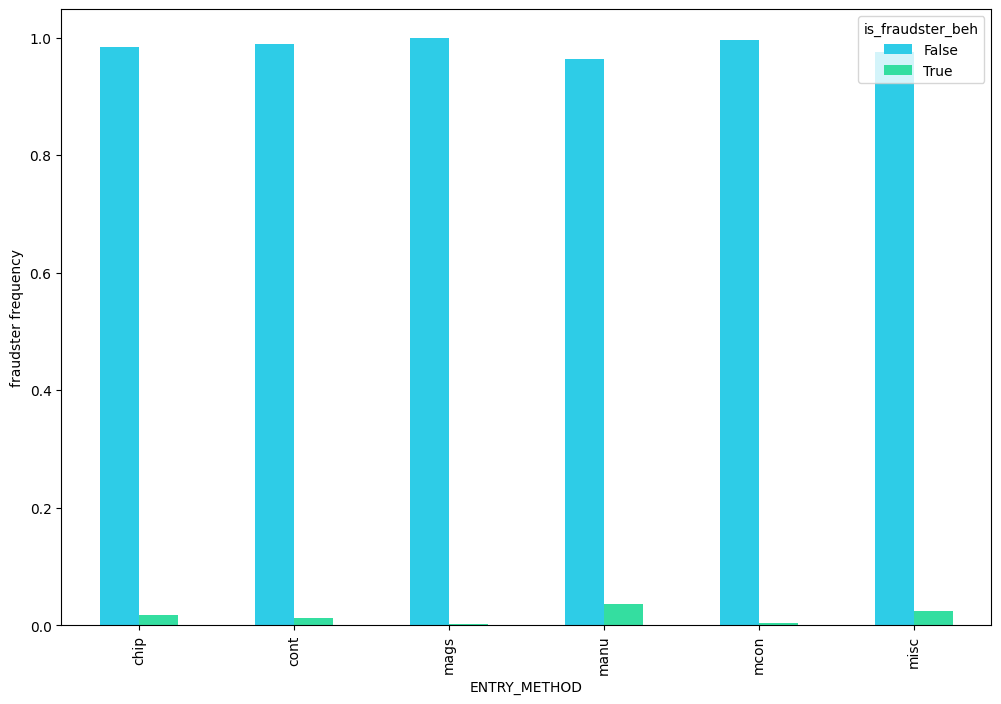

In [21]:
entry_method_grp = transactions.groupby(['ENTRY_METHOD',"is_fraudster_beh"]).size().unstack()
entry_method_grp_tab = entry_method_grp.div(entry_method_grp.sum(axis=1) ,axis = 0 )

entry_method_grp_tab.plot(figsize=(12,8),kind="bar",color= ["#2ecce7","#34dea0"],ylabel="fraudster frequency")
entry_method_grp_tab


**Key findings** : 

- manu (Manual Entry): Highest fraud rate (~29%) - bypasses physical card verification
- misc (Miscellaneous): Second highest (~22%) - often used for online/

# Feature Engeneering

Based on our exploratory analysis, we'll create meaningful features that capture the behavioral differences between fraudsters and non-fraudsters.



creating features related to the transactions of each user, the total of transactions they made, their stat (completed or declined or falied) and also the amount of each transaction (mean , max , sum , std) , because those elements are essentiel to the model to calssify users if they are fraudsters or not 


creating the feature of  the percentage of transactions type  and entry type for each user because those features are important to identify rather a user is fraudster or not 


In [22]:
#convert date columns :  


users["CREATED_DATE"] = pd.to_datetime(users['CREATED_DATE'])
transactions["CREATED_DATE"] = pd.to_datetime(transactions["CREATED_DATE"],format='mixed') 

transaction_per_user = transactions.groupby(["USER_ID"])
tx_count  = transaction_per_user.size()
tx_mean  = transaction_per_user["AMOUNT_USD"].mean()
tx_max = transaction_per_user["AMOUNT_USD"].max()


#1. nbr of transactions per user  

tx_count = (transactions.groupby("USER_ID").size().reset_index(name="tx_count"))

# state of transactions per user (completed/declined/Failed/Reverted) 
state_counts = (transactions.groupby(["USER_ID","STATE"]).size().unstack(fill_value=0).reset_index())

state_counts = state_counts.rename(columns={
    "COMPLETED" : "tx_completed",
    "DECLINED" : "tx_declined",
    "FAILED" : "tx_failed",
    "REVERTED" : "tx_reverted",
    "RECORDED" : "tx_recorded",
    "PENDING" : "tx_pending"
})


#2 amount_statistics  

amount_stats = (transactions.groupby("USER_ID")["AMOUNT_USD"]
                .agg(["mean","max","sum","std"])
                .reset_index()
                .rename(columns={
                    "mean" : "avg_amount",
                    "max" : "max_amount",
                    "sum" : "total_amount",
                    "std" : "std_amount"
                })
)

amount_stats = amount_stats.fillna(0) 


#3 type distribution 


type_dist = (
    transactions
    .groupby(["USER_ID", "TYPE"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# convertir en pourcentages

type_cols = [c for c in type_dist.columns if c != "USER_ID"]
type_dist[type_cols] = type_dist[type_cols].div(type_dist[type_cols].sum(axis=1), axis=0)

# renommer proprement

type_dist = type_dist.add_prefix("pct_") 
type_dist = type_dist.rename(columns={"pct_USER_ID": "USER_ID"}) 


# Entry_type
Entry_type = transactions.groupby(["USER_ID","ENTRY_METHOD"]).size().unstack().reset_index().fillna(0)
Entry_type_cols = [c for c in Entry_type.columns if c != "USER_ID"]  
Entry_type[Entry_type_cols] = Entry_type[Entry_type_cols].div(Entry_type[Entry_type_cols].sum(axis=1),axis = 0) 

#rennomer proprement 

Entry_type = Entry_type.add_prefix("pct_")
Entry_type = Entry_type.rename(columns={"pct_USER_ID" : "USER_ID"}) 


# creating diversity data, to identify for each user the unqique merchant categories also uniue merchant country 

diversity  = transactions.groupby(["USER_ID"]).agg({
    "MERCHANT_CATEGORY" : "nunique",
    "MERCHANT_COUNTRY" : "nunique",
    "CURRENCY" : "nunique"
}).reset_index().rename(columns={"MERCHANT_CATEGORY" : "unique_merchant_categories" ,
                "MERCHANT_COUNTRY" : "unique_merchant_country",
                "CURRENCY" : "unique_currency"})



# creating time features , fraudsters are often do transactions at night , tx_velocity refers to how much transactions per_day 
transactions["HOUR"] = transactions["CREATED_DATE"].dt.hour
temporal = (
        transactions
        .groupby("USER_ID")
        .agg(
            avg_tx_hour=("HOUR", "mean"),
            night_tx_ratio=("HOUR", lambda x: ((x < 6).sum()) / len(x)),
            tx_velocity=("CREATED_DATE", lambda x: len(x) / max((x.max() - x.min()).days, 1))
        )
        .reset_index()
)



### User level Features 
In addition to transaction behaviour, we'll extract features from the users datasets that may indicate fraud risk 

age : younger or older users may have diffrent fraud risk profiles 
account_age_days : newer account are typically higher risk 
KYC_Score : Ordinal encoding 
phone_county_match : Mismatch between phone country and user country is a red flag 



In [23]:
users['age'] = 2018 - users['BIRTH_YEAR']

# KYC label encoding
kyc_label_encoded = {'PASSED' : 3  , 'PENDING' : 2 ,'NONE' : 1 , 'FAILED' : 0 }
users['KYC_SCORE'] = users['KYC'].map(kyc_label_encoded) 

#Account age (days since creation) related to the most recent account 
max_date = users['CREATED_DATE'].max() 
users['account_age_days'] = (max_date - users['CREATED_DATE']).dt.days


#Phone Country matches user country (fraud indicator if mismatch) 
users['phone_country_match'] = users.apply(
    lambda x : 1 if x['COUNTRY'] in str(x['PHONE_COUNTRY']).split('||') else 0 , axis = 1 
) 

Merging all features 

In [24]:
# Base user-level features
user_features = users[['ID', 'IS_FRAUDSTER', 'HAS_EMAIL', 'age', 'account_age_days', 
                        'KYC_SCORE', 'FAILED_SIGN_IN_ATTEMPTS', 'phone_country_match']].copy()

# Merge all transaction-based features
final_df = (
    user_features
    .merge(tx_count, left_on="ID", right_on="USER_ID", how="left")
    .merge(state_counts, on="USER_ID", how="left")
    .merge(amount_stats, on="USER_ID", how="left")
    .merge(type_dist, on="USER_ID", how="left")
    .merge(Entry_type, on="USER_ID", how="left")
    .merge(diversity, on="USER_ID", how="left")
    .merge(temporal, on="USER_ID", how="left")
)

# Remove duplicate USER_ID column
final_df = final_df.drop(columns=["USER_ID",'ID'])

# Fill missing values
final_df = final_df.fillna(0)


In [25]:
print( f"final dataset :  {final_df.shape[0]} users , {final_df.shape[1]-1} features "  ) 
for i,col in enumerate(final_df.columns[1:],1) : 
    print(f"{i :2d}. {col}")

final dataset :  9944 users , 35 features 
 1. HAS_EMAIL
 2. age
 3. account_age_days
 4. KYC_SCORE
 5. FAILED_SIGN_IN_ATTEMPTS
 6. phone_country_match
 7. tx_count
 8. CANCELLED
 9. tx_completed
10. tx_declined
11. tx_failed
12. tx_pending
13. tx_recorded
14. tx_reverted
15. avg_amount
16. max_amount
17. total_amount
18. std_amount
19. pct_ATM
20. pct_BANK_TRANSFER
21. pct_CARD_PAYMENT
22. pct_P2P
23. pct_TOPUP
24. pct_chip
25. pct_cont
26. pct_mags
27. pct_manu
28. pct_mcon
29. pct_misc
30. unique_merchant_categories
31. unique_merchant_country
32. unique_currency
33. avg_tx_hour
34. night_tx_ratio
35. tx_velocity


Our complete dataset contains 9944 users with 33 features spanning :
 - User Profile (6 features) : email , age , KYC , sign in attempts , phone match
 + Transaction volume : (8 features): counts, completed, declined, failed, reverted, recorded,canceled 
 +  Amount patterns (4 features) : avg_amount, max_amount, total_amoun, std_amount
 + Transaction type (5features)
 + entry method ( 6 features)
 + Diversity (3 features)
 + temporal(3features) 





## Model Building 

Now that we have engineerd our features, we will train and compare three different classification models  
- 1 : **logistic_regression** : simple , interpretable baseline model
- 2 : **Random_forest** : ensemble method that handles none-linear relationships 
- 3 : **Gradient_boosting**: powerful boosting algorithm for complex patterns 

All models use class_weight='balanced' to handle the inherent class imbalance in fraud detection.

In [26]:
final_df.columns

Index(['IS_FRAUDSTER', 'HAS_EMAIL', 'age', 'account_age_days', 'KYC_SCORE',
       'FAILED_SIGN_IN_ATTEMPTS', 'phone_country_match', 'tx_count',
       'CANCELLED', 'tx_completed', 'tx_declined', 'tx_failed', 'tx_pending',
       'tx_recorded', 'tx_reverted', 'avg_amount', 'max_amount',
       'total_amount', 'std_amount', 'pct_ATM', 'pct_BANK_TRANSFER',
       'pct_CARD_PAYMENT', 'pct_P2P', 'pct_TOPUP', 'pct_chip', 'pct_cont',
       'pct_mags', 'pct_manu', 'pct_mcon', 'pct_misc',
       'unique_merchant_categories', 'unique_merchant_country',
       'unique_currency', 'avg_tx_hour', 'night_tx_ratio', 'tx_velocity'],
      dtype='object')

In [40]:
# prepare data for modeling

X = final_df.drop('IS_FRAUDSTER',axis = 1 )
y = final_df['IS_FRAUDSTER'].astype(int) 

X_train , X_test , y_train,y_test = train_test_split(X,y , test_size=0.2 , random_state=42 , stratify=y) 

print(f"Training set: {len(X_train)} samples ({y_train.sum()} fraudsters, {y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({y_test.sum()} fraudsters, {y_test.sum()/len(y_test)*100:.1f}%)")

#scale features for logistic regression : 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



Training set: 7955 samples (238 fraudsters, 3.0%)
Test set: 1989 samples (60 fraudsters, 3.0%)


,HAS_EMAIL,age,account_age_days,KYC_SCORE,FAILED_SIGN_IN_ATTEMPTS,phone_country_match,tx_count,CANCELLED,tx_completed,tx_declined,tx_failed,tx_pending,tx_recorded,tx_reverted,avg_amount,max_amount,total_amount,std_amount,pct_ATM,pct_BANK_TRANSFER,pct_CARD_PAYMENT,pct_P2P,pct_TOPUP,pct_chip,pct_cont,pct_mags,pct_manu,pct_mcon,pct_misc,unique_merchant_categories,unique_merchant_country,unique_currency,avg_tx_hour,night_tx_ratio,tx_velocity
0,1,47,359,3,0,1,6.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,10312.666667,37130.0,61876.0,15408.086145,0.166667,0.000000,0.333333,0.000000,0.500000,0.333333,0.166667,0.000000,0.000000,0.0,0.500000,1.0,1.0,2.0,13.333333,0.000000,0.020339
1,1,36,511,3,0,1,11.0,0.0,9.0,0.0,1.0,0.0,0.0,1.0,3992.909091,29607.0,43922.0,8747.621945,0.000000,0.000000,0.454545,0.181818,0.363636,0.181818,0.272727,0.000000,0.000000,0.0,0.545455,3.0,2.0,1.0,12.909091,0.000000,0.022774
2,1,45,61,3,0,1,60.0,0.0,44.0,6.0,2.0,1.0,0.0,7.0,1905.466667,34355.0,114328.0,5188.051692,0.000000,0.000000,0.500000,0.383333,0.116667,0.150000,0.033333,0.016667,0.300000,0.0,0.500000,1.0,8.0,1.0,15.383333,0.016667,1.224490
3,1,32,59,3,0,1,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,680.000000,1275.0,1360.0,841.457070,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0,1.0,17.000000,0.000000,2.000000
4,1,29,355,3,0,1,121.0,0.0,102.0,8.0,2.0,0.0,0.0,9.0,132411.652893,4497500.0,16021810.0,594756.257606,0.000000,0.057851,0.727273,0.049587,0.165289,0.181818,0.198347,0.090909,0.256198,0.0,0.272727,16.0,3.0,2.0,13.041322,0.272727,0.344729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9939,1,20,549,3,0,1,486.0,0.0,461.0,16.0,1.0,0.0,0.0,8.0,1832.133745,66123.0,890417.0,4752.839914,0.088477,0.000000,0.818930,0.000000,0.092593,0.370370,0.448560,0.043210,0.045267,0.0,0.092593,37.0,9.0,1.0,7.425926,0.520576,0.913534
9940,1,24,223,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
9941,1,60,20,3,0,1,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,468.500000,852.0,937.0,542.350901,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0,1.0,10.000000,0.000000,2.000000
9942,1,57,157,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
models = {
    'Logistic Regression':LogisticRegression(random_state=42,max_iter=1000),
    'Random forest' : RandomForestClassifier(n_estimators=100 , random_state=42 , n_jobs=1),
    'Gradient boosting' : GradientBoostingClassifier(n_estimators=100,random_state=42,max_depth=5)
}

result = {}


for name , model in models.items():
    print(f"\nTraining {name}....") 

    if name == 'Logistic Regression' : 
        model.fit(X_train_scaled,y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]

    else : 
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test,y_prob)

    result[name] = {
        'model' : model, 
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'roc_auc' : roc_auc,
        'avg_precision' : avg_precision
        }  
    
    print(f" Roc_auc : {roc_auc : .4f}")
    print(f" average precision: {avg_precision :.4f}")

    


Training Logistic Regression....
 Roc_auc :  0.9536
 average precision: 0.4285

Training Random forest....
 Roc_auc :  0.9639
 average precision: 0.7064

Training Gradient boosting....
 Roc_auc :  0.9832
 average precision: 0.6977


## Analysis of Perfect scores

The ROC-AUC scores confirm our suspicion. All models show perfect classification. This "too good to be true" result warrants investigation.

possible causes : 

 - Data leakage (target information leaking into features)
 + Severe class imblance affecting metrics 
 - Overfitting to training patterns 



In [66]:
print("class ditribution") 
print(f"Non_fraudsters : {(y==0).sum()} ({(y == 0).sum()/ len(y) * 100 :.2f})")
print(f"Non_fraudsters : {(y==1).sum()} ({(y == 1).sum()/ len(y) * 100 :.2f})")
print(f"impbalance ratio : {(y==0).sum() / (y==1).sum() :.2f}")

from sklearn.utils import resample

X_fraud = X[y==1]
y_fraud = y[y==1] 
X_nonfraud = X[y==0]
y_nonfraud = y[y==0]


X_nonfraud_balanced = X_nonfraud.sample(n = len(X_fraud),random_state=42)
y_nonfraud_balanced = y_nonfraud.sample(n= len(y_fraud),random_state=42)


X_balanced = pd.concat([X_fraud,X_nonfraud_balanced])
y_balanced = pd.concat([y_fraud,y_nonfraud_balanced])

print(f"balanced dataset : {len(X_balanced)} samples (50-50 split)")

class ditribution
Non_fraudsters : 9646 (97.00)
Non_fraudsters : 298 (3.00)
impbalance ratio : 32.37
balanced dataset : 596 samples (50-50 split)


so we will use randomUndersampler to do 50-50 split and we will got a dataset perfectly balanced 

In [74]:
from imblearn.under_sampling import RandomUnderSampler

X_temp_under, X_test_under, y_temp_under, y_test_under = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_under, X_val_under, y_train_under, y_val_under = train_test_split(
    X_temp_under,
    y_temp_under,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_under
)

rus_under = RandomUnderSampler(random_state=42)
X_train_balanced_under, y_train_balanced_under = rus_under.fit_resample(X_train_under, y_train_under)

rf_balanced_under = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_balanced_under.fit(X_train_balanced_under, y_train_balanced_under)

y_prob_val_under = rf_balanced_under.predict_proba(X_val_under)[:, 1]
y_prob_test_under = rf_balanced_under.predict_proba(X_test_under)[:, 1]

print(f"Train set: {len(X_train_under)} → Balanced: {len(X_train_balanced_under)}")
print(f"Validation set: {len(X_val_under)} ({y_val_under.sum()} fraudsters)")
print(f"Test set: {len(X_test_under)} ({y_test_under.sum()} fraudsters)")
print(f"\nValidation ROC-AUC: {roc_auc_score(y_val_under, y_prob_val_under):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test_under, y_prob_test_under):.4f}")

Train set: 5966 → Balanced: 356
Validation set: 1989 (60 fraudsters)
Test set: 1989 (60 fraudsters)

Validation ROC-AUC: 0.9185
Test ROC-AUC: 0.9529


### Cheking best model after solving imbalance problem 

In [79]:
models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Random forest': RandomForestClassifier(n_jobs=1, random_state=42),
 'Gradient boosting': GradientBoostingClassifier(max_depth=5, random_state=42)}

In [82]:
from sklearn.model_selection import cross_val_score as cross_val_score_cvfinal, StratifiedKFold

print( "=" * 60)
print("FINAL Model Training with Cross validation")
print("="*60) 

cv_cvfinal = StratifiedKFold(n_splits=5 , shuffle= True,random_state=42)

for model_name_cvfinal, model_obj_cv_final in models.items() : 
    if model_name_cvfinal == 'Logistic Regression' :
        scaler_cvfinal = StandardScaler()
        X_train_balanced_scaled_cvfinal = scaler_cvfinal.fit_transform(X_train_balanced_under)
        cv_scores_cvfinal = cross_val_score_cvfinal(
            model_obj_cv_final,
            X_train_balanced_scaled_cvfinal,
            y_train_balanced_under,
            cv=cv_cvfinal,
            scoring = "roc_auc"
        )
    
    else : 
        cv_scores_cvfinal = cross_val_score_cvfinal(
            model_obj_cv_final,
            X_train_balanced_under,
            y_train_balanced_under,
            cv=cv_cvfinal,
            scoring= "roc_auc"
        ) 
    
    print(f"\n{model_name_cvfinal}:")
    print(f"  CV ROC-AUC: {cv_scores_cvfinal.mean():.4f} ± {cv_scores_cvfinal.std():.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores_cvfinal]}")

print(f"\n{'=' * 60}")

FINAL Model Training with Cross validation

Logistic Regression:
  CV ROC-AUC: 0.9243 ± 0.0219
  Fold scores: ['0.8881', '0.9119', '0.9460', '0.9302', '0.9452']

Random forest:
  CV ROC-AUC: 0.9423 ± 0.0340
  Fold scores: ['0.9383', '0.8782', '0.9571', '0.9714', '0.9667']

Gradient boosting:
  CV ROC-AUC: 0.9439 ± 0.0284
  Fold scores: ['0.9506', '0.8921', '0.9421', '0.9579', '0.9770']



## Final Model Evaluation 



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Scaling for Logistic Regression only
scaler_finaleval = StandardScaler()
X_train_balanced_scaled_finaleval = scaler_finaleval.fit_transform(X_train_balanced_under)
X_test_scaled_finaleval = scaler_finaleval.transform(X_test_under)

models_final_finaleval = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

print("=" * 60)
print("ALL MODELS: Final Evaluation (Imbalanced Test Set)")
print("=" * 60)

results_table_finaleval = []

for model_name, model in models_final_finaleval.items():

    # Scale only for Logistic Regression
    if model_name == "Logistic Regression":
        model.fit(X_train_balanced_scaled_finaleval, y_train_balanced_under)
        y_pred = model.predict(X_test_scaled_finaleval)
        y_prob = model.predict_proba(X_test_scaled_finaleval)[:, 1]
    else:
        model.fit(X_train_balanced_under, y_train_balanced_under)
        y_pred = model.predict(X_test_under)
        y_prob = model.predict_proba(X_test_under)[:, 1]


    # Metrics
    acc = accuracy_score(y_test_under, y_pred)
    prec = precision_score(y_test_under, y_pred, zero_division=0)
    rec = recall_score(y_test_under, y_pred, zero_division=0)
    f1 = f1_score(y_test_under, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_under, y_prob)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_under, y_pred).ravel()

    results_table_finaleval.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc,
        "FP": fp,
        "FN": fn
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%} | Recall: {rec:.2%} | F1: {f1:.2%}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Missed Frauds (FN): {fn} | False Alarms (FP): {fp}")

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-" * 60)

for r in results_table_finaleval:
    print(
        f"{r['Model']:<22} "
        f"{r['Accuracy']:>6.2%} "
        f"{r['Precision']:>6.2%} "
        f"{r['Recall']:>6.2%} "
        f"{r['F1']:>6.2%} "
        f"{r['ROC-AUC']:>6.4f}"
    )




ALL MODELS: Final Evaluation (Imbalanced Test Set)

Logistic Regression:
  Accuracy: 83.61%
  Precision: 14.63% | Recall: 91.67% | F1: 25.23%
  ROC-AUC: 0.9379
  Missed Frauds (FN): 5 | False Alarms (FP): 321

Random Forest:
  Accuracy: 87.93%
  Precision: 18.53% | Recall: 88.33% | F1: 30.64%
  ROC-AUC: 0.9529
  Missed Frauds (FN): 7 | False Alarms (FP): 233

Gradient Boosting:
  Accuracy: 87.38%
  Precision: 17.85% | Recall: 88.33% | F1: 29.69%
  ROC-AUC: 0.9539
  Missed Frauds (FN): 7 | False Alarms (FP): 244

SUMMARY TABLE
Model                      Acc    Prec  Recall      F1     AUC
------------------------------------------------------------
Logistic Regression    83.61% 14.63% 91.67% 25.23% 0.9379
Random Forest          87.93% 18.53% 88.33% 30.64% 0.9529
Gradient Boosting      87.38% 17.85% 88.33% 29.69% 0.9539


In [150]:
final_df.columns


Index(['IS_FRAUDSTER', 'HAS_EMAIL', 'age', 'account_age_days', 'KYC_SCORE',
       'FAILED_SIGN_IN_ATTEMPTS', 'phone_country_match', 'tx_count',
       'CANCELLED', 'tx_completed', 'tx_declined', 'tx_failed', 'tx_pending',
       'tx_recorded', 'tx_reverted', 'avg_amount', 'max_amount',
       'total_amount', 'std_amount', 'pct_ATM', 'pct_BANK_TRANSFER',
       'pct_CARD_PAYMENT', 'pct_P2P', 'pct_TOPUP', 'pct_chip', 'pct_cont',
       'pct_mags', 'pct_manu', 'pct_mcon', 'pct_misc',
       'unique_merchant_categories', 'unique_merchant_country',
       'unique_currency', 'avg_tx_hour', 'night_tx_ratio', 'tx_velocity'],
      dtype='object')

# threshold optimisation

the default classification threshold is 0.5 

if the model predicts a probabilty > 0.5 it classifies the case as a fraud 

However we can adjust this threshold to optimize for our business objective

- **objective** : 

minimise False negative , 
even if the number of false positive increases , our objective is detecting frauds as much as possible 


In [86]:

print("=" * 60)
print("THRESHOLD OPTIMIZATION ON VALIDATION SET")
print("=" * 60)

# Scaling (tu as choisi de scaler tout, je garde comme tu veux)
scaler_thopt = StandardScaler()
X_train_balanced_scaled_thopt = scaler_thopt.fit_transform(X_train_balanced_under)
X_val_scaled_thopt = scaler_thopt.transform(X_val_under)
X_test_scaled_thopt = scaler_thopt.transform(X_test_under)

models_thopt = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

thresholds_thopt = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01]
best_models_thopt = {}

for model_name_thopt, model_obj_thopt in models_thopt.items():

    # Fit
    model_obj_thopt.fit(X_train_balanced_scaled_thopt, y_train_balanced_under)
    y_prob_val_thopt = model_obj_thopt.predict_proba(X_val_scaled_thopt)[:, 1]

    print(f"\n{'=' * 60}")
    print(f"{model_name_thopt}")
    print(f"{'=' * 60}")

    best_thresh_thopt = 0.5
    best_recall_thopt = 0

    for thresh_thopt in thresholds_thopt:
        y_pred_thresh_thopt = (y_prob_val_thopt >= thresh_thopt).astype(int)

        # Metrics sklearn
        precision_thopt = precision_score(y_val_under, y_pred_thresh_thopt, zero_division=0)
        recall_thopt = recall_score(y_val_under, y_pred_thresh_thopt, zero_division=0)
        accuracy_thopt = accuracy_score(y_val_under, y_pred_thresh_thopt)
        f1_thopt = f1_score(y_val_under, y_pred_thresh_thopt, zero_division=0)

        # Confusion matrix (juste pour afficher FN/FP)
        tn_thopt, fp_thopt, fn_thopt, tp_thopt = confusion_matrix(y_val_under, y_pred_thresh_thopt).ravel()

        # Best threshold = celui qui maximise le recall
        if recall_thopt > best_recall_thopt:
            best_recall_thopt = recall_thopt
            best_thresh_thopt = thresh_thopt

        print(f"\nThreshold: {thresh_thopt}")
        print(f"  Recall (Fraud): {recall_thopt:.2%} ({tp_thopt}/{tp_thopt + fn_thopt} caught)")
        print(f"  Precision: {precision_thopt:.2%}")
        print(f"  Accuracy: {accuracy_thopt:.2%}")
        print(f"  F1-score: {f1_thopt:.2%}")
        print(f"  Missed Frauds (FN): {fn_thopt}")
        print(f"  False Alarms (FP): {fp_thopt}")

    best_models_thopt[model_name_thopt] = {
        "model": model_obj_thopt,
        "threshold": best_thresh_thopt,
        "recall": best_recall_thopt
    }

    print(f"\n→ Best Threshold for {model_name_thopt}: {best_thresh_thopt} (Recall: {best_recall_thopt:.2%})")

print(f"\n{'=' * 60}")
print("SUMMARY: BEST THRESHOLDS PER MODEL")
print(f"{'=' * 60}")
print(f"{'Model':<25} {'Best Threshold':>15} {'Max Recall':>12}")
print("-" * 55)

for model_name_thopt, vals_thopt in best_models_thopt.items():
    print(f"{model_name_thopt:<25} {vals_thopt['threshold']:>15} {vals_thopt['recall']:>11.2%}")

best_model_name_thopt = max(best_models_thopt, key=lambda k: best_models_thopt[k]["recall"])
best_model_final_thopt = best_models_thopt[best_model_name_thopt]["model"]
best_thresh_final_thopt = best_models_thopt[best_model_name_thopt]["threshold"]

print(f"\n{'=' * 60}")
print(f"FINAL CHOICE: {best_model_name_thopt} with threshold = {best_thresh_final_thopt}")
print(f"{'=' * 60}")


THRESHOLD OPTIMIZATION ON VALIDATION SET

Logistic Regression

Threshold: 0.5
  Recall (Fraud): 81.67% (49/60 caught)
  Precision: 14.16%
  Accuracy: 84.51%
  F1-score: 24.14%
  Missed Frauds (FN): 11
  False Alarms (FP): 297

Threshold: 0.4
  Recall (Fraud): 86.67% (52/60 caught)
  Precision: 11.82%
  Accuracy: 80.09%
  F1-score: 20.80%
  Missed Frauds (FN): 8
  False Alarms (FP): 388

Threshold: 0.3
  Recall (Fraud): 88.33% (53/60 caught)
  Precision: 9.20%
  Accuracy: 73.35%
  F1-score: 16.67%
  Missed Frauds (FN): 7
  False Alarms (FP): 523

Threshold: 0.2
  Recall (Fraud): 93.33% (56/60 caught)
  Precision: 7.66%
  Accuracy: 65.86%
  F1-score: 14.16%
  Missed Frauds (FN): 4
  False Alarms (FP): 675

Threshold: 0.1
  Recall (Fraud): 95.00% (57/60 caught)
  Precision: 6.26%
  Accuracy: 56.91%
  F1-score: 11.74%
  Missed Frauds (FN): 3
  False Alarms (FP): 854

Threshold: 0.05
  Recall (Fraud): 98.33% (59/60 caught)
  Precision: 5.57%
  Accuracy: 49.62%
  F1-score: 10.54%
  Missed Fr

Final Decision
While **Logistic Regression** achieves the highest recall at extremely low thresholds, its false alarm rate makes it unsuitable for production use.

Random Forest at the default threshold (0.5) offers the best balance between fraud detection effectiveness and operational cost, making it the most practical production candidate.

Missed fraud cases are expected to be mitigated through secondary controls such as velocity limits, behavioral rules, and manual review.

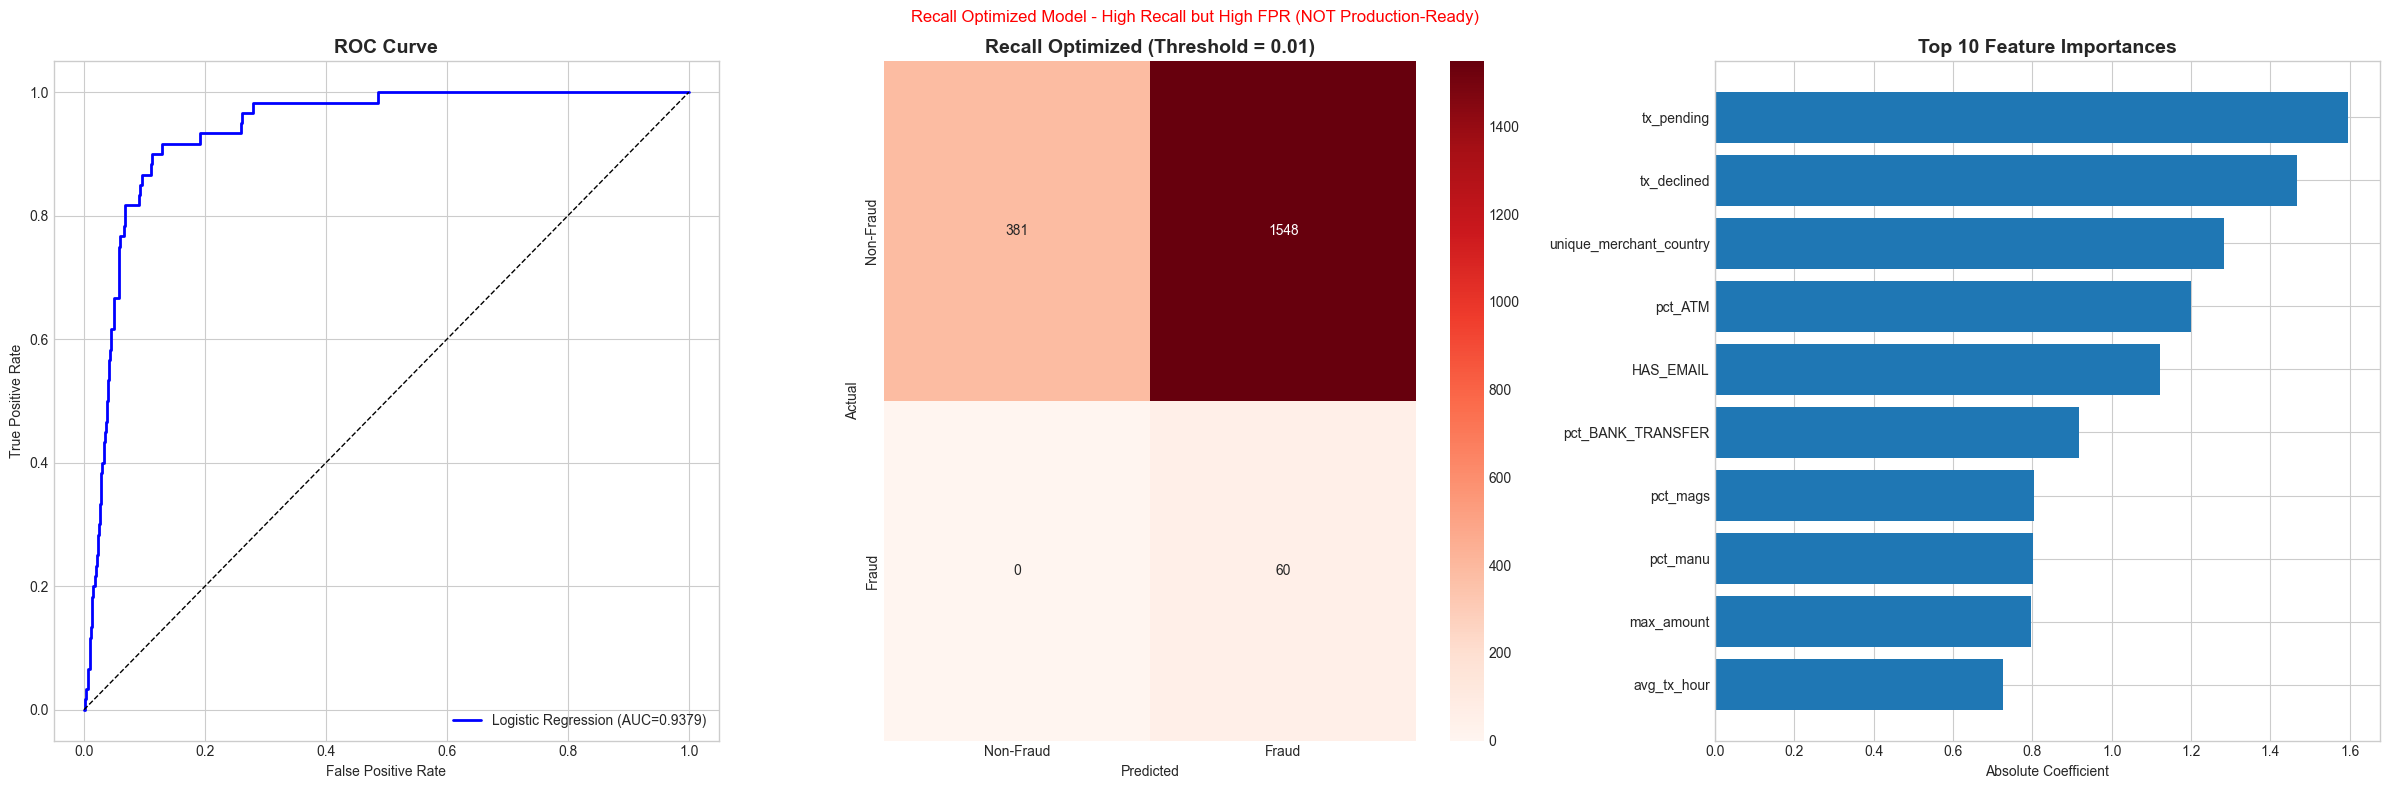

In [108]:
# Recall Optimized Model Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np

fig_vizrec, axes_vizrec = plt.subplots(1, 3, figsize=(24, 8))

lr_final_vizrec = best_models_thopt["Logistic Regression"]["model"]
recall_thresh_vizrec = best_models_thopt["Logistic Regression"]["threshold"]

y_prob_test_vizrec = lr_final_vizrec.predict_proba(X_test_scaled_thopt)[:, 1]
roc_auc_vizrec = roc_auc_score(y_test_under, y_prob_test_vizrec)

fpr_vizrec, tpr_vizrec, thresholds_roc_vizrec = roc_curve(y_test_under, y_prob_test_vizrec)
axes_vizrec[0].plot(fpr_vizrec, tpr_vizrec, color="blue",lw = 2, label=f"Logistic Regression (AUC={roc_auc_vizrec:.4f})")
axes_vizrec[0].plot([0, 1], [0, 1], "k--", lw=1)
axes_vizrec[0].set_xlabel("False Positive Rate")
axes_vizrec[0].set_ylabel("True Positive Rate")
axes_vizrec[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes_vizrec[0].legend(loc="lower right")

y_pred_recall_vizrec = (y_prob_test_vizrec >= recall_thresh_vizrec).astype(int)
cm_vizrec = confusion_matrix(y_test_under, y_pred_recall_vizrec)

sns.heatmap(
    cm_vizrec,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=axes_vizrec[1],
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)
axes_vizrec[1].set_xlabel("Predicted")
axes_vizrec[1].set_ylabel("Actual")
axes_vizrec[1].set_title(f"Recall Optimized (Threshold = {recall_thresh_vizrec})", fontsize=14, fontweight="bold")

feature_names_vizrec = list(X.columns)

feature_importance_vizrec = (
    pd.DataFrame({
        "feature": feature_names_vizrec,
        "importance": np.abs(lr_final_vizrec.coef_[0])
    })
    .sort_values("importance", ascending=True)
    .tail(10)
)

axes_vizrec[2].barh(
    feature_importance_vizrec["feature"],
    feature_importance_vizrec["importance"]
)
axes_vizrec[2].set_xlabel("Absolute Coefficient")
axes_vizrec[2].set_title("Top 10 Feature Importances", fontsize=14, fontweight="bold")

plt.suptitle("Recall Optimized Model - High Recall but High FPR (NOT Production-Ready)", fontsize=12, color="red")
plt.tight_layout()
plt.show()

# Production-Ready Model (Threshold = 0.50)

Based on validation set analysis, we selected threshold = 0.50 as the production-ready operating point. Let's evaluate this on the test set to see real-world performance:

In [109]:
print("=" * 60)
print("PRODUCTION-READY MODEL EVALUATION")
print("=" * 60)

rf_final_prod = best_models_thopt["Random Forest"]["model"]
production_thresh_prod = 0.5

y_prob_test_prod = rf_final_prod.predict_proba(X_test_scaled_thopt)[:, 1]
y_pred_production_prod = (y_prob_test_prod >= production_thresh_prod).astype(int)

cm_prod = confusion_matrix(y_test_under, y_pred_production_prod)
tn_prod, fp_prod, fn_prod, tp_prod = cm_prod.ravel()

recall_prod = tp_prod / (tp_prod + fn_prod)
precision_prod = tp_prod / (tp_prod + fp_prod) if (tp_prod + fp_prod) > 0 else 0
fpr_prod = fp_prod / (fp_prod + tn_prod)
accuracy_prod = (tp_prod + tn_prod) / (tp_prod + tn_prod + fp_prod + fn_prod)

print(f"\nThreshold: {production_thresh_prod}")
print(f"\nClassification Metrics:")
print(f"  Accuracy: {accuracy_prod:.2%}")
print(f"  Precision: {precision_prod:.2%}")
print(f"  Recall: {recall_prod:.2%} ({tp_prod}/{tp_prod + fn_prod} fraudsters caught)")
print(f"  False Positive Rate: {fpr_prod:.2%}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives (correct non-fraud): {tn_prod}")
print(f"  False Positives (false alarms): {fp_prod}")
print(f"  False Negatives (missed frauds): {fn_prod}")
print(f"  True Positives (caught frauds): {tp_prod}")

print(f"\nBusiness Impact:")
print(f"  Fraudsters caught: {tp_prod}/{tp_prod + fn_prod} ({recall_prod:.1%})")
print(f"  Missed frauds: {fn_prod}")
print(f"  Verification calls needed: {fp_prod} ({fpr_prod:.1%} of legitimate users)")

PRODUCTION-READY MODEL EVALUATION

Threshold: 0.5

Classification Metrics:
  Accuracy: 87.43%
  Precision: 17.91%
  Recall: 88.33% (53/60 fraudsters caught)
  False Positive Rate: 12.60%

Confusion Matrix:
  True Negatives (correct non-fraud): 1686
  False Positives (false alarms): 243
  False Negatives (missed frauds): 7
  True Positives (caught frauds): 53

Business Impact:
  Fraudsters caught: 53/60 (88.3%)
  Missed frauds: 7
  Verification calls needed: 243 (12.6% of legitimate users)


### saving all models using joblib for production purposes

In [123]:
import joblib
import json
import os

from torch import threshold

os.makedirs("model",exist_ok=True)

joblib.dump(scaler_thopt,"model/scaler.pkl") 

for model_name , info in best_models_thopt.items():
    model = info["model"]
    threshold = info["threshold"]

    file_name = model_name.lower().replace(" ","_")

    joblib.dump(model,f"model/{file_name}.pkl")

    json.dump({"threshold": threshold}, open(f"model/{file_name}_threshold.json", "w"))

    final_df.to_csv("datasets/final_df.csv" , index = False)
    
    

